In [41]:
# reading in the libraries and functions that we will need as we do this work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [42]:
clerical= pd.read_csv("C:/Users/preci/Downloads/ProdTime.csv")

clerical.dropna(inplace=True)
clerical.head()

,day,PRODTIME,MONEY,MAIL,WINDOW,CHANGE,CHECKS,MISC,BUS
0,M,128.5,7781,100,886,235,644,56,737
1,T,113.6,7004,110,962,388,589,57,1029
2,W,146.6,7267,61,1342,398,1081,59,830
3,Th,124.3,2129,102,1153,457,891,57,1468
4,F,100.4,4878,45,803,577,537,49,335


In [43]:
clerical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   day       52 non-null     object 
 1   PRODTIME  52 non-null     float64
 2   MONEY     52 non-null     int64  
 3   MAIL      52 non-null     int64  
 4   WINDOW    52 non-null     int64  
 5   CHANGE    52 non-null     int64  
 6   CHECKS    52 non-null     int64  
 7   MISC      52 non-null     int64  
 8   BUS       52 non-null     int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 3.8+ KB


In [107]:
#Creating a Simple model, using money vs productivity time

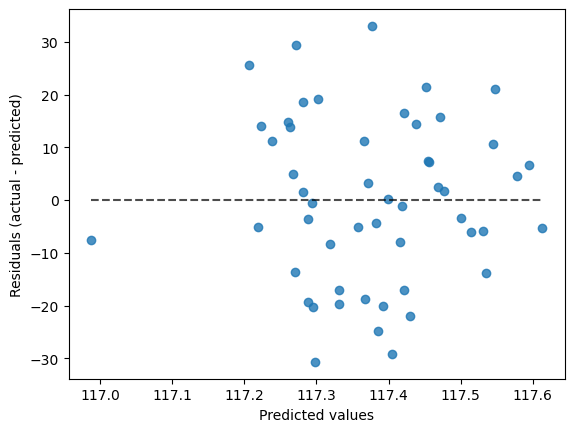

In [93]:
#first running a simple linear regression, and finding the fit of the model
# and here it is a linear regression object
clerical_model1= LinearRegression()

#extracting the x as a 2D array
clerical_x= clerical[['MONEY']]
#extracting y as a 1D series
clerical_y= clerical['PRODTIME']

#fitting the model
clerical_model1.fit(clerical_x, clerical_y)

#making the fitted vs the residual plot
clerical_yhat= clerical_model1.predict(clerical_x)

#displaying the predicted values vs the residual values
display = PredictionErrorDisplay(y_true=clerical_y, y_pred=clerical_yhat)
display.plot()
plt.show()


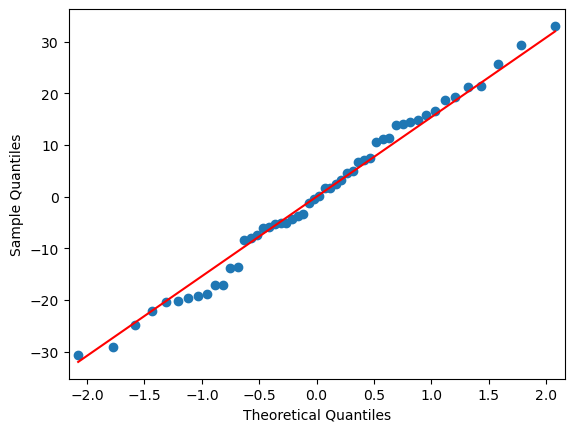

In [95]:
#forming a qqplot to asses the distribution of points

# get the predicted values from the model
clerical_yhat = clerical_model1.predict(clerical_x)  
# calculate the residuals 
clerical_residuals = clerical_y -clerical_yhat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(clerical_residuals, line ='s') 
# 
py.show() 

In [ ]:
#from the plot we can see that there is a slight dip in the bottom left and in the right the values are above the line.

In [97]:
#fit linear regression model
clerical_model1 = sm.OLS(clerical_y, clerical_x).fit()

#view model summary
print(clerical_model1.summary())

                                 OLS Regression Results                                
Dep. Variable:               PRODTIME   R-squared (uncentered):                   0.883
Model:                            OLS   Adj. R-squared (uncentered):              0.881
Method:                 Least Squares   F-statistic:                              385.7
Date:                Sat, 15 Feb 2025   Prob (F-statistic):                    1.95e-25
Time:                        18:02:27   Log-Likelihood:                         -266.19
No. Observations:                  52   AIC:                                      534.4
Df Residuals:                      51   BIC:                                      536.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [99]:
# Evaluate the model via the RMSE
rmse = root_mean_squared_error(clerical_y, clerical_yhat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 15.38717730981063


In [115]:
#creating a Multiple regression model with money, bus, and mail as predictor variables

# first i create a model object to for multiple linear regression
#using day of the number of mail sized items , window payments transacted, and day of the week  

clerical_model= LinearRegression()

x= clerical[['MONEY','BUS','MAIL']]
y= clerical['PRODTIME']

#fit the model on the data
clerical_model.fit(x, y)

y_hat = clerical_model.predict(x)


# Evaluate the model performance
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)


print('Coefficients:', clerical_model.coef_)
print('Intercept:', clerical_model.intercept_)


Root Mean Squared Error: 13.095604182784196
Coefficients: [0.00110083 0.01918452 0.10234204]
Intercept: 87.45423476141895


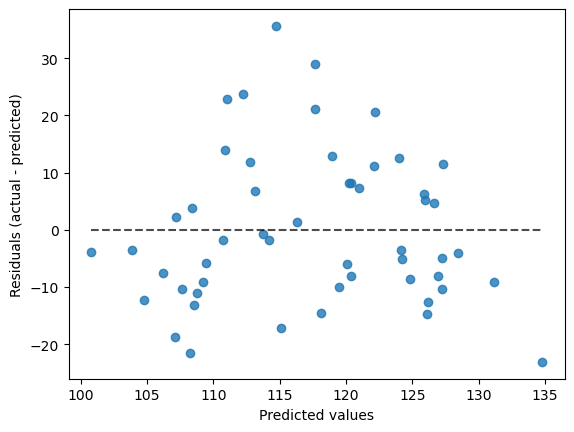

In [117]:
#viewing the residuals vs fitted plot

# below makes a residual plot
display = PredictionErrorDisplay(y_true=y, y_pred=y_hat)
display.plot()
plt.show()

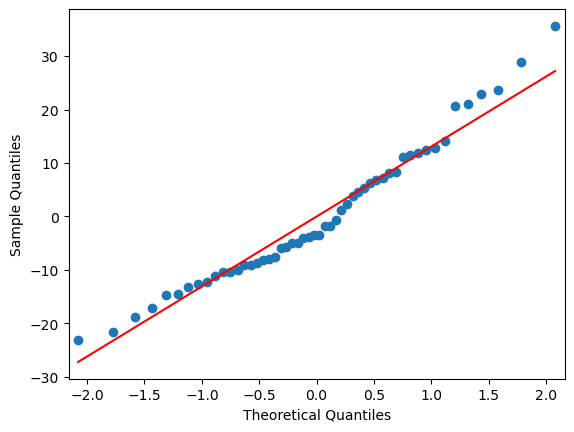

In [119]:
# calculate the residuals 
clerical_residuals = y - y_hat
# generate the qq plot and put a line through the points to help us visualize the relationship here    
sm.qqplot(clerical_residuals, line ='s') 
# 
py.show() 

In [111]:
#view model summary
model = sm.OLS(y, x).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:               PRODTIME   R-squared (uncentered):                   0.965
Model:                            OLS   Adj. R-squared (uncentered):              0.963
Method:                 Least Squares   F-statistic:                              453.7
Date:                Sat, 15 Feb 2025   Prob (F-statistic):                    9.99e-36
Time:                        18:16:48   Log-Likelihood:                         -234.68
No. Observations:                  52   AIC:                                      475.4
Df Residuals:                      49   BIC:                                      481.2
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [121]:
#condition number is moderate so that could indicates there might be slight multicollinearity

rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 13.095604182784196


In [125]:
#INterpretation , Rsquared, ftest, pvalues, coefficients, rmse

#Our RMSE here is 

In [ ]:
# creating a model with more than one predictor variable and interaction
#my predictors will include day of the week as a variable for productivity time

In [ ]:
#creating graphical summaries to understand the distribution of the data

plt.hist(clerical['PRODTIME'], color= "purple")
plt.xlabel('PRODTIME')
plt.ylabel('Frequency')
plt.title('Histogram of Production time')
plt.show()


In [131]:
x2 = clerical[['MAIL','MONEY', 'day']]  
y = clerical['PRODTIME']  


# Create a linear regression model
clerical_model2 = LinearRegression()

# Fit the model on the  data
clerical_model2.fit(x, y)

# Make predictions on the  data
y_hat = clerical_model2.predict(x)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 13.095604182784196


In [133]:
clerical_model2 = sm.OLS(y, x).fit()

#view model summary
print(clerical_model2.summary())

                                 OLS Regression Results                                
Dep. Variable:               PRODTIME   R-squared (uncentered):                   0.965
Model:                            OLS   Adj. R-squared (uncentered):              0.963
Method:                 Least Squares   F-statistic:                              453.7
Date:                Sat, 15 Feb 2025   Prob (F-statistic):                    9.99e-36
Time:                        19:13:47   Log-Likelihood:                         -234.68
No. Observations:                  52   AIC:                                      475.4
Df Residuals:                      49   BIC:                                      481.2
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [63]:
#counts for different days of the week
clerical['day'].value_counts()

day
M     9
T     9
W     9
Th    9
F     8
S     8
Name: count, dtype: int64

In [65]:
# make indicator/dummy variables for day of the week
# each day gets a different column
one_hot=pd.get_dummies(clerical['day'],dtype=int)
print(one_hot)
clerical=clerical.join(one_hot)
clerical.head()

    F  M  S  T  Th  W
0   0  1  0  0   0  0
1   0  0  0  1   0  0
2   0  0  0  0   0  1
3   0  0  0  0   1  0
4   1  0  0  0   0  0
5   0  0  1  0   0  0
6   0  1  0  0   0  0
7   0  0  0  1   0  0
8   0  0  0  0   0  1
9   0  0  0  0   1  0
10  1  0  0  0   0  0
11  0  0  1  0   0  0
12  0  1  0  0   0  0
13  0  0  0  1   0  0
14  0  0  0  0   0  1
15  0  0  0  0   1  0
16  1  0  0  0   0  0
17  0  0  1  0   0  0
18  0  1  0  0   0  0
19  0  0  0  1   0  0
20  0  0  0  0   0  1
21  0  0  0  0   1  0
22  1  0  0  0   0  0
23  0  0  1  0   0  0
24  0  1  0  0   0  0
25  0  0  0  1   0  0
26  0  0  0  0   0  1
27  0  0  0  0   1  0
28  1  0  0  0   0  0
29  0  0  1  0   0  0
30  0  1  0  0   0  0
31  0  0  0  1   0  0
32  0  0  0  0   0  1
33  0  0  0  0   1  0
34  1  0  0  0   0  0
35  0  0  1  0   0  0
36  0  1  0  0   0  0
37  0  0  0  1   0  0
38  0  0  0  0   0  1
39  0  0  0  0   1  0
40  1  0  0  0   0  0
41  0  0  1  0   0  0
42  0  1  0  0   0  0
43  0  0  0  1   0  0
44  0  0  

,day,PRODTIME,MONEY,MAIL,WINDOW,CHANGE,CHECKS,MISC,BUS,F,M,S,T,Th,W
0,M,128.5,7781,100,886,235,644,56,737,0,1,0,0,0,0
1,T,113.6,7004,110,962,388,589,57,1029,0,0,0,1,0,0
2,W,146.6,7267,61,1342,398,1081,59,830,0,0,0,0,0,1
3,Th,124.3,2129,102,1153,457,891,57,1468,0,0,0,0,1,0
4,F,100.4,4878,45,803,577,537,49,335,1,0,0,0,0,0


<Axes: xlabel='MAIL', ylabel='PRODTIME'>

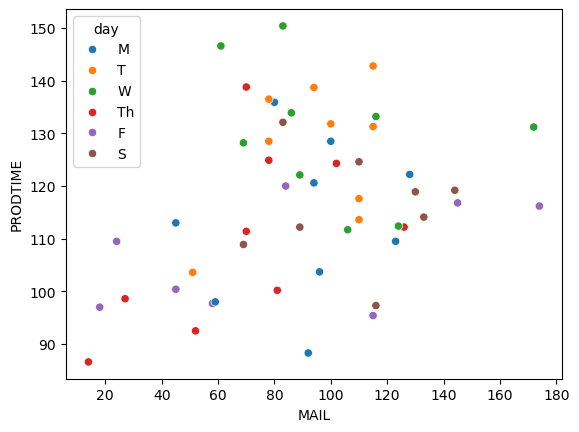

In [69]:
sns.scatterplot(data=clerical, x='MAIL', y='PRODTIME', hue='day')

<Axes: xlabel='BUS', ylabel='PRODTIME'>

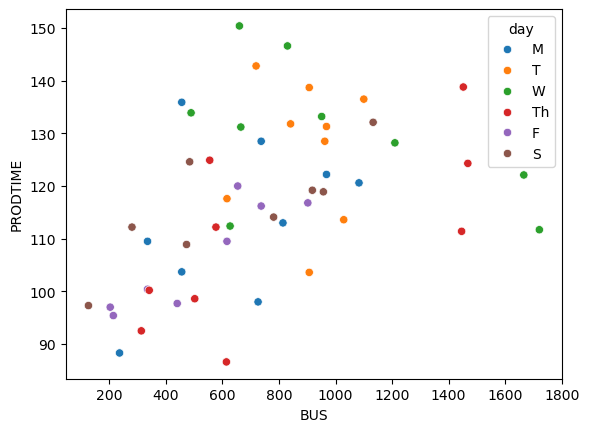

In [75]:
sns.scatterplot(data=clerical, x='BUS', y='PRODTIME', hue='day')

<Axes: xlabel='MONEY', ylabel='PRODTIME'>

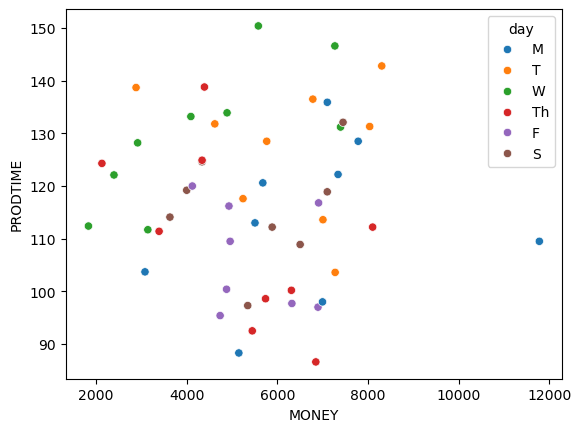

In [73]:
sns.scatterplot(data=clerical, x='MONEY', y='PRODTIME', hue='day')

In [79]:
# interactions of MAIL items with day of week
clerical['Mail_M'] = clerical['MAIL']*clerical['M']
clerical['Mail_F'] = clerical['MAIL']*clerical['F']
clerical['Mail_S'] = clerical['MAIL']*clerical['S']

# interactions of BUS Tickets sold with day of week
clerical['Bus_M'] = clerical['BUS']*clerical['M']
clerical['Bus_F'] = clerical['BUS']*clerical['F']
clerical['Bus_S'] = clerical['BUS']*clerical['S']

# interactions of money Tickets sold with day of week
clerical['Money_M'] = clerical['MONEY']*clerical['M']
clerical['Money_F'] = clerical['MONEY']*clerical['F']
clerical['Money_S'] = clerical['MONEY']*clerical['S']

In [139]:
#creating interaction terms

# interactions of MAIL items with day of week
clerical['Mail_day'] = clerical['MAIL']*clerical['day']

# interactions of BUS Tickets sold with day of week
clerical['Bus_day'] = clerical['BUS']*clerical['day']

# interactions of money Tickets sold with day of week
clerical['Money_day'] = clerical['MONEY']*clerical['day']


In [157]:
x = clerical[['MAIL', 'BUS', 'MONEY']]  
y = clerical['PRODTIME']  

# Create a linear regression model
clerical_model3 = LinearRegression()

# Fit the model on the  data
clerical_model3.fit(x, y)

# Make predictions on the  data
y_hat = clerical_model3.predict(x)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

Root Mean Squared Error: 13.095604182784196


<Axes: ylabel='PRODTIME'>

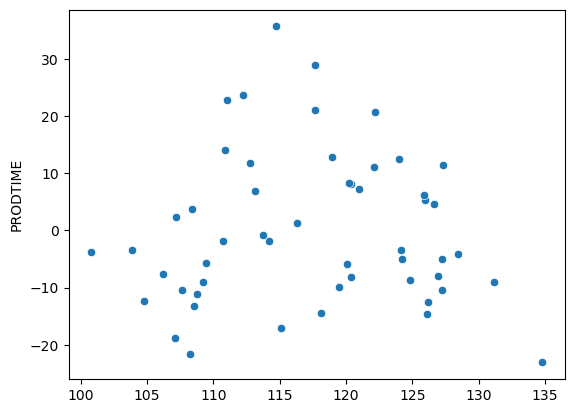

In [159]:
# a look at the residual vs fitted plot
sns.scatterplot(x=y_hat, y=y-y_hat)

In [161]:
#fit linear regression model
model3 = sm.OLS(y, x).fit()

#view model summary
print(model3.summary())

                                 OLS Regression Results                                
Dep. Variable:               PRODTIME   R-squared (uncentered):                   0.965
Model:                            OLS   Adj. R-squared (uncentered):              0.963
Method:                 Least Squares   F-statistic:                              453.7
Date:                Sat, 15 Feb 2025   Prob (F-statistic):                    9.99e-36
Time:                        22:18:23   Log-Likelihood:                         -234.68
No. Observations:                  52   AIC:                                      475.4
Df Residuals:                      49   BIC:                                      481.2
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------